In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install lightgbm joblib

In [3]:
import os
import re
import json
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

In [4]:
RANDOM_STATE = 42

EXPERIMENT_NAME = "tfidf_lexicon_only_lightgbm_same_params"

BASE_DIR = "/content/drive/MyDrive/CS114/TeamModel"
DATA_DIR = os.path.join(BASE_DIR, "data")

TRAIN_PATH = os.path.join(DATA_DIR, "train_clean_tokenizedEmoji.csv")
VAL_PATH = os.path.join(DATA_DIR, "val_clean_tokenizedEmoji.csv")
TEST_PATH = os.path.join(DATA_DIR, "test_clean_tokenizedEmoji.csv")

ARTIFACT_ROOT = os.path.join(BASE_DIR, "experiments", EXPERIMENT_NAME)
CHECKPOINT_DIR = os.path.join(ARTIFACT_ROOT, "checkpoints")
REPORT_DIR = os.path.join(ARTIFACT_ROOT, "reports")
ERROR_DIR = os.path.join(ARTIFACT_ROOT, "errors")
FIGURE_DIR = os.path.join(ARTIFACT_ROOT, "figures")

for d in [ARTIFACT_ROOT, CHECKPOINT_DIR, REPORT_DIR, ERROR_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

DROP_CROSS_SPLIT_DUPLICATES = True

FEATURE_K = 35000

WORD_NGRAM_RANGE = (1, 3)
CHAR_ANALYZER = "char_wb"
CHAR_NGRAM_RANGE = (3, 5)

WORD_MAX_FEATURES = 30000
CHAR_MAX_FEATURES = 30000
WORD_MIN_DF = 3
CHAR_MIN_DF = 3

FORCE_TRAIN = False

LGB_N_ESTIMATORS = 300
LGB_LEARNING_RATE = 0.05
LGB_NUM_LEAVES = 31
LGB_CLASS_WEIGHT = "balanced"

LEXICON_FEATURES = [
    "depression_keyword_count",
    "suicide_keyword_count",
]

DEPRESSION_KEYWORDS = [
    "depress", "sad", "hopeless", "worthless", "empty",
    "cry", "lonely", "tired", "pain", "numb"
]

SUICIDE_KEYWORDS = [
    "suicide", "suicidal", "kill myself", "kms", "kys", "end my life",
    "want to die", "wanna die", "die", "death", "overdose", "jump",
    "cut", "hurt myself", "hang myself"
]

MODEL_BUNDLE_PATH = os.path.join(
    CHECKPOINT_DIR,
    f"{EXPERIMENT_NAME}__lightgbm_bundle.joblib"
)

CONFIG_PATH = os.path.join(
    CHECKPOINT_DIR,
    f"{EXPERIMENT_NAME}__config.json"
)

config = {
    "EXPERIMENT_NAME": EXPERIMENT_NAME,
    "DROP_CROSS_SPLIT_DUPLICATES": DROP_CROSS_SPLIT_DUPLICATES,
    "FEATURE_K": FEATURE_K,
    "CHI2_APPLIED_TO": "tfidf_features_only",
    "WORD_NGRAM_RANGE": WORD_NGRAM_RANGE,
    "CHAR_ANALYZER": CHAR_ANALYZER,
    "CHAR_NGRAM_RANGE": CHAR_NGRAM_RANGE,
    "WORD_MAX_FEATURES": WORD_MAX_FEATURES,
    "CHAR_MAX_FEATURES": CHAR_MAX_FEATURES,
    "WORD_MIN_DF": WORD_MIN_DF,
    "CHAR_MIN_DF": CHAR_MIN_DF,
    "LGB_CLASS_WEIGHT": LGB_CLASS_WEIGHT,
    "LGB_N_ESTIMATORS": LGB_N_ESTIMATORS,
    "LGB_LEARNING_RATE": LGB_LEARNING_RATE,
    "LGB_NUM_LEAVES": LGB_NUM_LEAVES,
    "FEATURE_MODE": "tfidf_plus_depression_suicide_lexicon_only",
    "LEXICON_FEATURES": LEXICON_FEATURES,
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Experiment:", EXPERIMENT_NAME)
print("Artifact root:", ARTIFACT_ROOT)
print(json.dumps(config, indent=2, ensure_ascii=False))

Experiment: tfidf_lexicon_only_lightgbm_same_params
Artifact root: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_lexicon_only_lightgbm_same_params
{
  "EXPERIMENT_NAME": "tfidf_lexicon_only_lightgbm_same_params",
  "DROP_CROSS_SPLIT_DUPLICATES": true,
  "FEATURE_K": 35000,
  "CHI2_APPLIED_TO": "tfidf_features_only",
  "WORD_NGRAM_RANGE": [
    1,
    3
  ],
  "CHAR_ANALYZER": "char_wb",
  "CHAR_NGRAM_RANGE": [
    3,
    5
  ],
  "WORD_MAX_FEATURES": 30000,
  "CHAR_MAX_FEATURES": 30000,
  "WORD_MIN_DF": 3,
  "CHAR_MIN_DF": 3,
  "LGB_CLASS_WEIGHT": "balanced",
  "LGB_N_ESTIMATORS": 300,
  "LGB_LEARNING_RATE": 0.05,
  "LGB_NUM_LEAVES": 31,
  "FEATURE_MODE": "tfidf_plus_depression_suicide_lexicon_only",
  "LEXICON_FEATURES": [
    "depression_keyword_count",
    "suicide_keyword_count"
  ]
}


In [5]:
def load_split(path):
    df = pd.read_csv(path)
    df = df.dropna(subset=["text", "status"]).copy()
    df["text"] = df["text"].astype(str)
    df["status"] = df["status"].astype(str).str.strip().str.lower()
    return df


train_raw = load_split(TRAIN_PATH)
val_raw = load_split(VAL_PATH)
test_raw = load_split(TEST_PATH)

print("Before duplicate/overlap handling:")
print("Train:", train_raw.shape)
print("Val:  ", val_raw.shape)
print("Test: ", test_raw.shape)

print("\nTrain labels:")
print(train_raw["status"].value_counts())

print("\nVal labels:")
print(val_raw["status"].value_counts())

print("\nTest labels:")
print(test_raw["status"].value_counts())

Before duplicate/overlap handling:
Train: (34601, 2)
Val:   (4943, 2)
Test:  (9887, 2)

Train labels:
status
normal        12706
depression    10154
suicidal       7840
anxiety        3901
Name: count, dtype: int64

Val labels:
status
normal        1815
depression    1451
suicidal      1120
anxiety        557
Name: count, dtype: int64

Test labels:
status
normal        3630
depression    2902
suicidal      2240
anxiety       1115
Name: count, dtype: int64


In [6]:
def normalize_text_key(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


for df in [train_raw, val_raw, test_raw]:
    df["text_key"] = df["text"].apply(normalize_text_key)


if DROP_CROSS_SPLIT_DUPLICATES:
    train_keys = set(train_raw["text_key"])

    before_val = len(val_raw)
    val_raw = val_raw[~val_raw["text_key"].isin(train_keys)].copy()
    after_val = len(val_raw)

    train_val_keys = set(train_raw["text_key"]) | set(val_raw["text_key"])

    before_test = len(test_raw)
    test_raw = test_raw[~test_raw["text_key"].isin(train_val_keys)].copy()
    after_test = len(test_raw)

    print("Removed from val due to train overlap:", before_val - after_val)
    print("Removed from test due to train/val overlap:", before_test - after_test)


train_raw = train_raw.drop(columns=["text_key"])
val_raw = val_raw.drop(columns=["text_key"])
test_raw = test_raw.drop(columns=["text_key"])

print("\nAfter duplicate/overlap handling:")
print("Train:", train_raw.shape)
print("Val:  ", val_raw.shape)
print("Test: ", test_raw.shape)

Removed from val due to train overlap: 4
Removed from test due to train/val overlap: 12

After duplicate/overlap handling:
Train: (34601, 2)
Val:   (4939, 2)
Test:  (9875, 2)


In [7]:
def count_keywords(text, keywords):
    text = str(text).lower()
    return sum(
        len(re.findall(r"\b" + re.escape(kw) + r"\b", text))
        for kw in keywords
    )


def prepare_tfidf_lexicon_dataframe(df):
    """
    Chuẩn bị dataframe cho cấu hình TF-IDF + lexicon-only.

    Thiết kế:
    - Tạo `cleaned_text` cho word/char TF-IDF.
    - Chỉ tạo 2 manual lexicon features:
      + depression_keyword_count
      + suicide_keyword_count
    - Không dùng các surface-level manual features như độ dài, dấu câu, URL, emoji...
    - Chi-square chỉ áp dụng cho TF-IDF; 2 lexicon features được MinMaxScaler và ghép sau Chi-square.
    """
    df_out = df.copy()
    raw_text = df_out["text"].astype(str)

    df_out["cleaned_text"] = raw_text.str.lower().str.strip()

    # Rút gọn ký tự lặp cực dài, giữ giống notebook gốc
    df_out["cleaned_text"] = df_out["cleaned_text"].apply(
        lambda x: re.sub(r"(.)\1{4,}", r"\1\1", x)
    )

    df_out["depression_keyword_count"] = df_out["cleaned_text"].apply(
        lambda x: count_keywords(x, DEPRESSION_KEYWORDS)
    )

    df_out["suicide_keyword_count"] = df_out["cleaned_text"].apply(
        lambda x: count_keywords(x, SUICIDE_KEYWORDS)
    )

    return df_out


train_enriched = prepare_tfidf_lexicon_dataframe(train_raw)
val_enriched = prepare_tfidf_lexicon_dataframe(val_raw)
test_enriched = prepare_tfidf_lexicon_dataframe(test_raw)

y_train = train_enriched["status"].values
y_val = val_enriched["status"].values
y_test = test_enriched["status"].values

class_names = np.array(sorted(train_enriched["status"].unique()))

print("Classes:", class_names)
print("Feature mode: TF-IDF + Depression/Suicide lexicon only")
print("Lexicon features:", LEXICON_FEATURES)
print("Train:", train_enriched.shape)
print("Val:  ", val_enriched.shape)
print("Test: ", test_enriched.shape)

display(train_enriched.head())

Classes: ['anxiety' 'depression' 'normal' 'suicidal']
Feature mode: TF-IDF + Depression/Suicide lexicon only
Lexicon features: ['depression_keyword_count', 'suicide_keyword_count']
Train: (34601, 5)
Val:   (4939, 5)
Test:  (9875, 5)


,text,status,cleaned_text,depression_keyword_count,suicide_keyword_count
0,is anime bad ? is anime bad ? i think it's bad...,normal,is anime bad ? is anime bad ? i think it's bad...,0,0
1,horror wench me too i feel like i ve been on t...,normal,horror wench me too i feel like i ve been on t...,0,0
2,context: my father-in-law is/was the ultimate ...,normal,context: my father-in-law is/was the ultimate ...,0,0
3,been trying the whole online dating thing have...,suicidal,been trying the whole online dating thing have...,3,0
4,"selling passive caucasian instagram followers,...",normal,"selling passive caucasian instagram followers,...",0,0


In [8]:
def build_text_preprocessor():
    """
    Build word-level and character-level TF-IDF features.

    Chi-square feature selection will be applied only to TF-IDF features.
    Lexicon numeric features are appended after Chi-square.
    """
    return FeatureUnion([
        ("word_ngram", TfidfVectorizer(
            analyzer="word",
            ngram_range=WORD_NGRAM_RANGE,
            min_df=WORD_MIN_DF,
            max_df=0.90,
            max_features=WORD_MAX_FEATURES,
            sublinear_tf=True,
            dtype=np.float32
        )),
        ("char_ngram", TfidfVectorizer(
            analyzer=CHAR_ANALYZER,
            ngram_range=CHAR_NGRAM_RANGE,
            min_df=CHAR_MIN_DF,
            max_features=CHAR_MAX_FEATURES,
            sublinear_tf=True,
            dtype=np.float32
        ))
    ])


def build_numeric_preprocessor():
    """
    Scale lexicon count features to a non-negative range.

    These features are not scored by Chi-square. They are appended after
    TF-IDF feature selection to avoid applying chi-square directly to manual
    continuous/count features.
    """
    return Pipeline([
        ("scaler", MinMaxScaler())
    ])


def transform_with_feature_pipeline(X, feature_pipeline):
    text_preprocessor = feature_pipeline["text_preprocessor"]
    tfidf_selector = feature_pipeline["tfidf_selector"]
    numeric_preprocessor = feature_pipeline["numeric_preprocessor"]
    lexicon_features = feature_pipeline["lexicon_features"]

    X_text = text_preprocessor.transform(X["cleaned_text"])
    X_text_selected = tfidf_selector.transform(X_text)

    X_num = numeric_preprocessor.transform(X[lexicon_features])
    X_num = csr_matrix(X_num.astype(np.float32))

    return hstack([X_text_selected, X_num], format="csr")


def fit_transform_features_train_val_test(X_train_df, y_train_arr, X_val_df, X_test_df):
    """
    Fit the feature pipeline only on train data, then transform val/test.

    Pipeline:
    1. Fit word/char TF-IDF only on training text.
    2. Apply SelectKBest(chi2) only on TF-IDF features.
    3. Fit MinMaxScaler only on training lexicon features.
    4. Concatenate selected TF-IDF + scaled lexicon features.
    """
    text_preprocessor = build_text_preprocessor()
    numeric_preprocessor = build_numeric_preprocessor()

    # 1) TF-IDF fitted only on train text
    X_train_text = text_preprocessor.fit_transform(X_train_df["cleaned_text"])
    X_val_text = text_preprocessor.transform(X_val_df["cleaned_text"])
    X_test_text = text_preprocessor.transform(X_test_df["cleaned_text"])

    # 2) Chi-square only on TF-IDF features
    k_eff = min(FEATURE_K, X_train_text.shape[1])
    tfidf_selector = SelectKBest(score_func=chi2, k=k_eff)

    X_train_text_selected = tfidf_selector.fit_transform(X_train_text, y_train_arr)
    X_val_text_selected = tfidf_selector.transform(X_val_text)
    X_test_text_selected = tfidf_selector.transform(X_test_text)

    # 3) Scale lexicon features only with train data
    X_train_num = numeric_preprocessor.fit_transform(X_train_df[LEXICON_FEATURES])
    X_val_num = numeric_preprocessor.transform(X_val_df[LEXICON_FEATURES])
    X_test_num = numeric_preprocessor.transform(X_test_df[LEXICON_FEATURES])

    X_train_num = csr_matrix(X_train_num.astype(np.float32))
    X_val_num = csr_matrix(X_val_num.astype(np.float32))
    X_test_num = csr_matrix(X_test_num.astype(np.float32))

    # 4) Concatenate selected TF-IDF + lexicon features
    X_train_fe = hstack([X_train_text_selected, X_train_num], format="csr")
    X_val_fe = hstack([X_val_text_selected, X_val_num], format="csr")
    X_test_fe = hstack([X_test_text_selected, X_test_num], format="csr")

    feature_pipeline = {
        "text_preprocessor": text_preprocessor,
        "tfidf_selector": tfidf_selector,
        "numeric_preprocessor": numeric_preprocessor,
        "lexicon_features": LEXICON_FEATURES,
        "chi2_applied_to": "tfidf_features_only",
        "feature_mode": "tfidf_plus_depression_suicide_lexicon_only",
        "tfidf_feature_k": k_eff,
        "n_tfidf_features_before_chi2": X_train_text.shape[1],
        "n_tfidf_features_after_chi2": X_train_text_selected.shape[1],
        "n_lexicon_features_appended_after_chi2": len(LEXICON_FEATURES),
        "n_final_features": X_train_fe.shape[1],
    }

    print("TF-IDF features before chi2:", X_train_text.shape[1])
    print("TF-IDF features after chi2: ", X_train_text_selected.shape[1])
    print("Lexicon features appended: ", len(LEXICON_FEATURES))
    print("Final feature dimension:   ", X_train_fe.shape[1])

    return X_train_fe, X_val_fe, X_test_fe, feature_pipeline


def make_lightgbm_model():
    return LGBMClassifier(
        class_weight=LGB_CLASS_WEIGHT,
        n_estimators=LGB_N_ESTIMATORS,
        learning_rate=LGB_LEARNING_RATE,
        num_leaves=LGB_NUM_LEAVES,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )


print("Model: LightGBM")
print("WORD_NGRAM_RANGE:", WORD_NGRAM_RANGE)
print("CHAR_ANALYZER:", CHAR_ANALYZER)
print("CHAR_NGRAM_RANGE:", CHAR_NGRAM_RANGE)
print("FEATURE_K:", FEATURE_K)
print("Chi-square applied to: TF-IDF features only")
print("Lexicon features appended after chi2:", LEXICON_FEATURES)
print("LightGBM params:")
print({
    "class_weight": LGB_CLASS_WEIGHT,
    "n_estimators": LGB_N_ESTIMATORS,
    "learning_rate": LGB_LEARNING_RATE,
    "num_leaves": LGB_NUM_LEAVES,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
})

Model: LightGBM
WORD_NGRAM_RANGE: (1, 3)
CHAR_ANALYZER: char_wb
CHAR_NGRAM_RANGE: (3, 5)
FEATURE_K: 35000
Chi-square applied to: TF-IDF features only
Lexicon features appended after chi2: ['depression_keyword_count', 'suicide_keyword_count']
LightGBM params:
{'class_weight': 'balanced', 'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [9]:
if (not FORCE_TRAIN) and os.path.exists(MODEL_BUNDLE_PATH):
    print("Found existing LightGBM checkpoint. Loading bundle...")

    bundle = joblib.load(MODEL_BUNDLE_PATH)
    feature_pipeline = bundle["feature_pipeline"]
    lgb_model = bundle["model"]
    class_names = bundle["class_names"]

    X_train_fe = transform_with_feature_pipeline(train_enriched, feature_pipeline)
    X_val_fe = transform_with_feature_pipeline(val_enriched, feature_pipeline)
    X_test_fe = transform_with_feature_pipeline(test_enriched, feature_pipeline)

    print("Loaded bundle:", MODEL_BUNDLE_PATH)
    print("Train features:", X_train_fe.shape)
    print("Val features:  ", X_val_fe.shape)
    print("Test features: ", X_test_fe.shape)

else:
    print("No usable checkpoint found, or FORCE_TRAIN=True.")
    print("Fitting TF-IDF/chi2/scaler on train data only...")

    X_train_fe, X_val_fe, X_test_fe, feature_pipeline = fit_transform_features_train_val_test(
        X_train_df=train_enriched,
        y_train_arr=y_train,
        X_val_df=val_enriched,
        X_test_df=test_enriched
    )

    print("\nTraining LightGBM...")
    lgb_model = make_lightgbm_model()
    lgb_model.fit(X_train_fe, y_train)

    bundle = {
        "experiment_name": EXPERIMENT_NAME,
        "feature_pipeline": feature_pipeline,
        "model": lgb_model,
        "class_names": class_names,
        "config": config,
    }

    joblib.dump(bundle, MODEL_BUNDLE_PATH)
    print("Saved LightGBM bundle:", MODEL_BUNDLE_PATH)

No usable checkpoint found, or FORCE_TRAIN=True.
Fitting TF-IDF/chi2/scaler on train data only...
TF-IDF features before chi2: 60000
TF-IDF features after chi2:  35000
Lexicon features appended:  2
Final feature dimension:    35002

Training LightGBM...
Saved LightGBM bundle: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_lexicon_only_lightgbm_same_params/checkpoints/tfidf_lexicon_only_lightgbm_same_params__lightgbm_bundle.joblib


In [10]:
VALIDATION_REPORT_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__validation_report.txt"
)

preds_train = lgb_model.predict(X_train_fe)
preds_val = lgb_model.predict(X_val_fe)

acc_train = accuracy_score(y_train, preds_train)
acc_val = accuracy_score(y_val, preds_val)

f1_train = f1_score(y_train, preds_train, average="macro")
f1_val = f1_score(y_val, preds_val, average="macro")

print("\n==================================================")
print("Model                 : LightGBM")
print(f"Macro F1 - Train      : {f1_train:.4f}")
print(f"Macro F1 - Val        : {f1_val:.4f}")
print(f"Gap Train - Val       : {f1_train - f1_val:.4f}")
print(f"Accuracy - Train      : {acc_train:.4f}")
print(f"Accuracy - Val        : {acc_val:.4f}")
print("==================================================")

train_report = classification_report(
    y_train,
    preds_train,
    digits=4,
    zero_division=0
)

val_report = classification_report(
    y_val,
    preds_val,
    digits=4,
    zero_division=0
)

print("\n--- TRAIN SET ---")
print(train_report)

print("\n--- VALIDATION SET ---")
print(val_report)

with open(VALIDATION_REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(f"VALIDATION REPORT - {EXPERIMENT_NAME}\n")
    f.write("=" * 80 + "\n\n")
    f.write("Model: LightGBM\\n")
    f.write(f"LightGBM params: {lgb_model.get_params()}\\n\\n")
    f.write(f"Accuracy Train: {acc_train:.4f}\\n")
    f.write(f"Accuracy Val:   {acc_val:.4f}\\n")
    f.write(f"Macro F1 Train: {f1_train:.4f}\\n")
    f.write(f"Macro F1 Val:   {f1_val:.4f}\\n")
    f.write(f"Gap Train-Val:  {f1_train - f1_val:.4f}\\n\\n")
    f.write("--- TRAIN SET ---\\n")
    f.write(train_report)
    f.write("\\n\\n--- VALIDATION SET ---\\n")
    f.write(val_report)

print("Saved validation report:", VALIDATION_REPORT_PATH)


Model                 : LightGBM
Macro F1 - Train      : 0.9591
Macro F1 - Val        : 0.8021
Gap Train - Val       : 0.1570
Accuracy - Train      : 0.9582
Accuracy - Val        : 0.8131

--- TRAIN SET ---
              precision    recall  f1-score   support

     anxiety     0.9682    0.9987    0.9832      3901
  depression     0.9722    0.9096    0.9399     10154
      normal     0.9760    0.9845    0.9803     12706
    suicidal     0.9093    0.9582    0.9331      7840

    accuracy                         0.9582     34601
   macro avg     0.9564    0.9627    0.9591     34601
weighted avg     0.9589    0.9582    0.9581     34601


--- VALIDATION SET ---
              precision    recall  f1-score   support

     anxiety     0.8061    0.8582    0.8313       557
  depression     0.7734    0.6940    0.7316      1451
      normal     0.9129    0.9426    0.9275      1812
    suicidal     0.7016    0.7355    0.7182      1119

    accuracy                         0.8131      4939
   macr

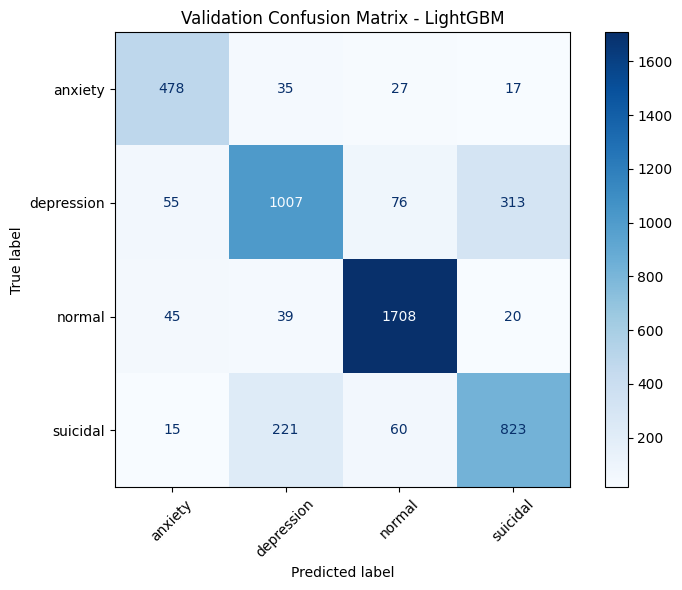

Saved validation confusion matrix: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_lexicon_only_lightgbm_same_params/figures/tfidf_lexicon_only_lightgbm_same_params__validation_confusion_matrix.png


In [11]:
cm_val = confusion_matrix(
    y_val,
    preds_val,
    labels=class_names
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Validation Confusion Matrix - LightGBM")
plt.tight_layout()

cm_val_path = os.path.join(
    FIGURE_DIR,
    f"{EXPERIMENT_NAME}__validation_confusion_matrix.png"
)

plt.savefig(cm_val_path, dpi=200)
plt.show()

print("Saved validation confusion matrix:", cm_val_path)

In [12]:
SUMMARY_PATH = os.path.join(
    BASE_DIR,
    "experiments",
    "single_model_tfidf_lexicon_only_summary.csv"
)

summary_row = {
    "experiment_name": EXPERIMENT_NAME,
    "model": "LightGBM",
    "feature_mode": "tfidf_plus_depression_suicide_lexicon_only",
    "val_macro_f1": float(f1_val),
    "train_macro_f1": float(f1_train),
    "gap_train_val": float(f1_train - f1_val),
    "val_accuracy": float(acc_val),
    "train_accuracy": float(acc_train),
    "lgb_class_weight": LGB_CLASS_WEIGHT,
    "lgb_n_estimators": LGB_N_ESTIMATORS,
    "lgb_learning_rate": LGB_LEARNING_RATE,
    "lgb_num_leaves": LGB_NUM_LEAVES,
}

if os.path.exists(SUMMARY_PATH):
    old_summary = pd.read_csv(SUMMARY_PATH)
    new_summary = pd.concat(
        [old_summary, pd.DataFrame([summary_row])],
        ignore_index=True
    )
else:
    new_summary = pd.DataFrame([summary_row])

new_summary.to_csv(
    SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved summary:", SUMMARY_PATH)

display(
    new_summary.sort_values(
        "val_macro_f1",
        ascending=False
    ).head(20)
)

Saved summary: /content/drive/MyDrive/CS114/TeamModel/experiments/single_model_tfidf_lexicon_only_summary.csv


,experiment_name,model,feature_mode,val_macro_f1,train_macro_f1,gap_train_val,val_accuracy,train_accuracy,lgb_class_weight,lgb_n_estimators,lgb_learning_rate,lgb_num_leaves
0,tfidf_lexicon_only_lightgbm_same_params,LightGBM,tfidf_plus_depression_suicide_lexicon_only,0.802131,0.95911,0.156979,0.81312,0.958151,balanced,300,0.05,31



Model                 : LightGBM
Val Macro F1          : 0.8021
Final Test Accuracy   : 0.8177
Final Test Macro F1   : 0.8089
              precision    recall  f1-score   support

     anxiety     0.8255    0.8618    0.8432      1114
  depression     0.7700    0.7145    0.7412      2900
      normal     0.9275    0.9319    0.9297      3625
    suicidal     0.6999    0.7446    0.7216      2236

    accuracy                         0.8177      9875
   macro avg     0.8057    0.8132    0.8089      9875
weighted avg     0.8182    0.8177    0.8174      9875

Saved final test report: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_lexicon_only_lightgbm_same_params/reports/tfidf_lexicon_only_lightgbm_same_params__final_test_report.txt


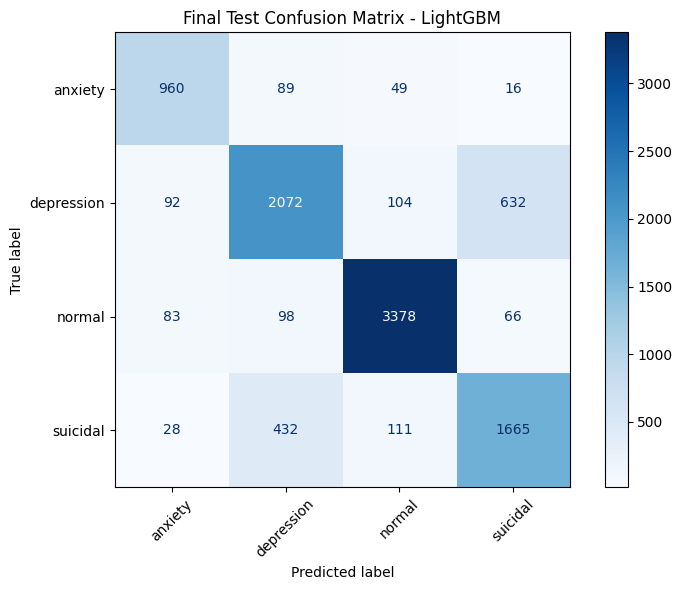

Saved final test confusion matrix: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_lexicon_only_lightgbm_same_params/figures/tfidf_lexicon_only_lightgbm_same_params__final_test_confusion_matrix.png


In [13]:
RUN_FINAL_TEST = True

if RUN_FINAL_TEST:
    preds_test = lgb_model.predict(X_test_fe)

    f1_test = f1_score(
        y_test,
        preds_test,
        average="macro"
    )

    acc_test = accuracy_score(
        y_test,
        preds_test
    )

    print("\n==================================================")
    print("Model                 : LightGBM")
    print(f"Val Macro F1          : {f1_val:.4f}")
    print(f"Final Test Accuracy   : {acc_test:.4f}")
    print(f"Final Test Macro F1   : {f1_test:.4f}")
    print("==================================================")

    test_report = classification_report(
        y_test,
        preds_test,
        digits=4,
        zero_division=0
    )

    print(test_report)

    final_test_report_path = os.path.join(
        REPORT_DIR,
        f"{EXPERIMENT_NAME}__final_test_report.txt"
    )

    with open(final_test_report_path, "w", encoding="utf-8") as f:
        f.write(f"FINAL TEST REPORT - {EXPERIMENT_NAME}\\n")
        f.write("=" * 80 + "\\n\\n")
        f.write("Model: LightGBM\\n")
        f.write(f"LightGBM params: {lgb_model.get_params()}\\n\\n")
        f.write(f"Val Macro F1:        {f1_val:.4f}\\n")
        f.write(f"Final Test Accuracy: {acc_test:.4f}\\n")
        f.write(f"Final Test Macro F1: {f1_test:.4f}\\n\\n")
        f.write(test_report)

    print("Saved final test report:", final_test_report_path)

    cm_test = confusion_matrix(
        y_test,
        preds_test,
        labels=class_names
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_test,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
    plt.title("Final Test Confusion Matrix - LightGBM")
    plt.tight_layout()

    cm_test_path = os.path.join(
        FIGURE_DIR,
        f"{EXPERIMENT_NAME}__final_test_confusion_matrix.png"
    )

    plt.savefig(cm_test_path, dpi=200)
    plt.show()

    print("Saved final test confusion matrix:", cm_test_path)

In [14]:
INFERENCE_REPORT_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__inference_time_report.json"
)

INFERENCE_SUMMARY_CSV_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__inference_time_summary.csv"
)


def predict_full_pipeline_with_timing(df_input):
    """
    Measures full inference time from enriched dataframe -> feature transform -> LightGBM predict.
    """
    start_time = time.perf_counter()

    X_fe = transform_with_feature_pipeline(
        df_input,
        feature_pipeline
    )

    preds = lgb_model.predict(X_fe)

    if hasattr(lgb_model, "predict_proba"):
        proba = lgb_model.predict_proba(X_fe)
    else:
        proba = None

    total_time = time.perf_counter() - start_time

    return preds, proba, total_time


warmup_n = min(10, len(test_enriched))

_ = predict_full_pipeline_with_timing(
    test_enriched.iloc[:warmup_n].copy()
)

print(f"Warm-up completed on {warmup_n} samples.")


preds_test_timed, proba_test_timed, test_inference_time = predict_full_pipeline_with_timing(
    test_enriched.copy()
)

test_inference_time_per_sample = test_inference_time / len(test_enriched)

test_acc_timed = accuracy_score(y_test, preds_test_timed)
test_macro_f1_timed = f1_score(y_test, preds_test_timed, average="macro")

print("\n================ INFERENCE TIME REPORT ================")
print(f"Number of test samples            : {len(test_enriched)}")
print(f"Total test inference time         : {test_inference_time:.6f} seconds")
print(f"Average inference time per sample : {test_inference_time_per_sample:.8f} seconds/sample")
print(f"Test Accuracy                     : {test_acc_timed:.4f}")
print(f"Test Macro F1                     : {test_macro_f1_timed:.4f}")
print("=======================================================")

print(
    classification_report(
        y_test,
        preds_test_timed,
        digits=4,
        zero_division=0
    )
)


inference_report = {
    "experiment_name": EXPERIMENT_NAME,
    "measurement_type": "full_pipeline_inference",
    "description": (
        "Measures full inference time from enriched raw dataframe through "
        "TF-IDF/chi2/scaler feature pipeline and LightGBM prediction."
    ),
    "n_test_samples": int(len(test_enriched)),
    "total_test_inference_time_seconds": float(test_inference_time),
    "average_inference_time_per_sample_seconds": float(test_inference_time_per_sample),
    "test_accuracy": float(test_acc_timed),
    "test_macro_f1": float(test_macro_f1_timed),
    "model": "LightGBM",
    "class_list": [str(c) for c in class_names],
    "lightgbm_params": lgb_model.get_params(),
}

with open(INFERENCE_REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(inference_report, f, ensure_ascii=False, indent=2)

inference_summary_df = pd.DataFrame([
    {
        "experiment_name": EXPERIMENT_NAME,
        "measurement_type": "full_pipeline_inference",
        "n_test_samples": len(test_enriched),
        "total_inference_time_seconds": test_inference_time,
        "inference_time_per_sample_seconds": test_inference_time_per_sample,
        "test_accuracy": test_acc_timed,
        "test_macro_f1": test_macro_f1_timed,
    }
])

inference_summary_df.to_csv(
    INFERENCE_SUMMARY_CSV_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved inference time report:")
print(INFERENCE_REPORT_PATH)

print("\nSaved inference time summary CSV:")
print(INFERENCE_SUMMARY_CSV_PATH)

Warm-up completed on 10 samples.

================ INFERENCE TIME REPORT ================
Number of test samples            : 9875
Total test inference time         : 13.181321 seconds
Average inference time per sample : 0.00133482 seconds/sample
Test Accuracy                     : 0.8177
Test Macro F1                     : 0.8089
              precision    recall  f1-score   support

     anxiety     0.8255    0.8618    0.8432      1114
  depression     0.7700    0.7145    0.7412      2900
      normal     0.9275    0.9319    0.9297      3625
    suicidal     0.6999    0.7446    0.7216      2236

    accuracy                         0.8177      9875
   macro avg     0.8057    0.8132    0.8089      9875
weighted avg     0.8182    0.8177    0.8174      9875


Saved inference time report:
/content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_lexicon_only_lightgbm_same_params/reports/tfidf_lexicon_only_lightgbm_same_params__inference_time_report.json

Saved inference time summary CSV:


In [15]:
PACKAGE_DIR = "/content/drive/MyDrive/CS114/TeamModel/demo_model"
os.makedirs(PACKAGE_DIR, exist_ok=True)

PACKAGE_PATH = os.path.join(
    PACKAGE_DIR,
    "tfidf_lexicon_only_lightgbm_same_params_demo_bundle.joblib"
)

required_vars = [
    "feature_pipeline",
    "lgb_model",
    "class_names",
    "EXPERIMENT_NAME"
]

missing_vars = [
    var for var in required_vars
    if var not in globals()
]

if missing_vars:
    raise NameError(
        f"Thiếu các biến cần thiết để đóng gói model: {missing_vars}. "
        "Hãy chạy xong phần train/load LightGBM trước."
    )

print("All required variables are available.")

demo_bundle = {
    "experiment_name": EXPERIMENT_NAME,
    "feature_pipeline": feature_pipeline,
    "model": lgb_model,
    "class_names": np.array(class_names),
    "feature_k": FEATURE_K,
    "word_ngram_range": WORD_NGRAM_RANGE,
    "char_analyzer": CHAR_ANALYZER,
    "char_ngram_range": CHAR_NGRAM_RANGE,
    "lexicon_features": LEXICON_FEATURES,
    "lightgbm_params": lgb_model.get_params(),
    "note": (
        "Standalone TF-IDF + lexicon-only LightGBM model bundle. "
        "LightGBM parameters are copied from the submitted ensemble notebook. "
        "Includes feature pipeline and trained LightGBM model."
    )
}

joblib.dump(demo_bundle, PACKAGE_PATH)

print("\nSaved LightGBM demo model bundle:")
print(PACKAGE_PATH)

All required variables are available.

Saved LightGBM demo model bundle:
/content/drive/MyDrive/CS114/TeamModel/demo_model/tfidf_lexicon_only_lightgbm_same_params_demo_bundle.joblib
